In [1]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from fluxonium_classes import *

### Constants and unit conversions

In [2]:
e = 1.602*10**(-19)
h = 6.626*10**(-34)
phi_0 = h/(2*e)
unit_fF_inv_to_GHz = e**2 /h * 10**6
unit_nH_inv_to_GHz = 1/h * (phi_0/(2*np.pi))**2

### Fluxonium wavefunctions

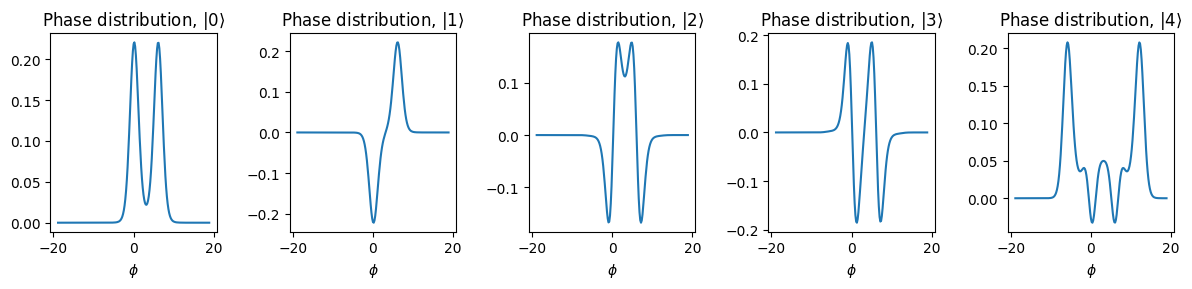

In [3]:

# from Zhang, Chicago paper 2021, all in GHz
E_L = 0.132
C_J = 2 #fF
C = 38 #fF, want to satisfy E_C = 0.479 GHz
E_J = 3.395

N_wavfuncs = 5
ext_phase = np.pi

flux1 = Fluxonium(E_J, C_J, C, E_L, N_phi = 201)
flux1.plot_wavefuncs(N_wavfuncs, ext_phase)

### Fluxoniums transitions frequencies from ground state

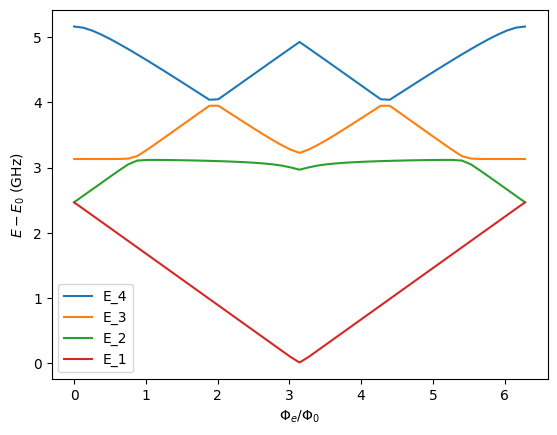

In [4]:
N_en_levels = 5
N_flux = 51
ext_phase = np.linspace(0, 2*np.pi, N_flux)
flux1.plot_transistions_over_flux(ext_phase, N_en_levels)
plt.legend()

### Testing tracking of eigenstates over flux

In [5]:
h1 = flux1.get_h_bare(ext_phase[0])
evals_prev, evecs_prev = h1.eigenstates()

tracked_energies = np.zeros((N_flux, N_en_levels))
tracked_energies[0] = evals_prev[:5]

for i in range(1, N_flux):

    h = flux1.get_h_bare(ext_phase[i])
    evals, evecs = h.eigenstates()

    state_indices = flux1.identify_state_index(
        evecs_prev[:5],
        evecs[:5]
    )

    tracked_energies[i] = evals[state_indices]

    evecs_prev = [evecs[idx] for idx in state_indices]

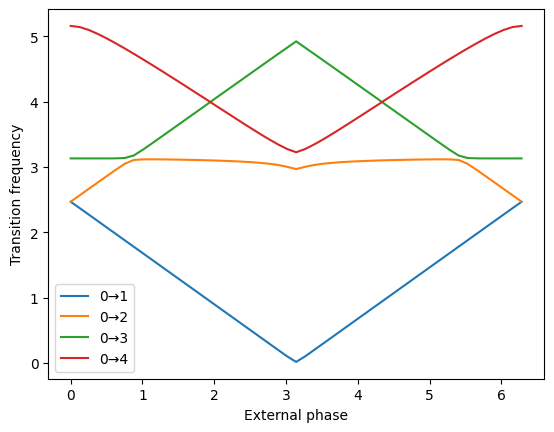

In [6]:
plt.figure()

for excited in range(1, N_en_levels):
    transition_freq = tracked_energies[:, excited] - tracked_energies[:, 0]

    plt.plot(
        ext_phase,
        transition_freq,
        label=f"0→{excited}"
    )

plt.xlabel("External phase")
plt.ylabel("Transition frequency")
plt.legend()
plt.show()

### Adding a resonator capacitively coupled to the fluxonium
Here it is also possible to add a list of resonators, by replacing gamma by an array or list

In [6]:
resonator_list = []
cap_mat_list = []

#gammas = np.linspace(0.5, 1.5, 5)
gammas = [1]
Cr = 300 #fF
Lr = 5 #nH
fock_dim = 6

Cg = 10 # fF

N_flux = 11
ext_phase = np.linspace(np.pi - 0.25, np.pi + 0.25, N_flux)

for gamma in gammas:
    res = Resonator(Lr, Cr, fock_dim)
    resonator_list.append(res)

    cap_mat = np.matrix([

                [C+C_J + Cg, -Cg],

                [-Cg, Cg + Cr]

            ])
    
    cap_mat_list.append(cap_mat)

flux1.add_resonator_coupling(resonator_list, cap_mat_list)

res1 = resonator_list[0]

### Plotting the transitions from the groundstate for the coupled fluxonium-resonator hamiltonian

/var/folders/s5/cbjrw4s55l14k7j6d64ldnmm0000gn/T/ipykernel_20986/722312947.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_over_flux_mat[phi_e_idx, i] = es[i] - es[0]


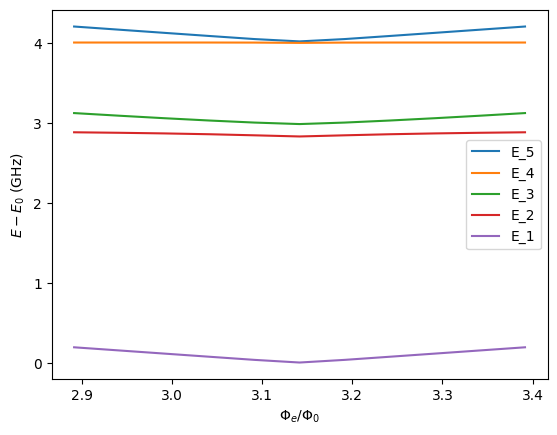

In [7]:
N_levels = 6
energy_over_flux_mat = np.empty((N_flux, N_levels))
for phi_e_idx, phi_e in enumerate(ext_phase):
    H = flux1.get_h_effs(phi_e)
    H_tot = tensor(H[0], qeye(res1.fock_dim)) + tensor(qeye(flux1.N_phi), res1.get_h_eff()) + flux1.res_couplings[0]
    es, tstates = H_tot.eigenstates()

    for i in range(1, N_levels):
                energy_over_flux_mat[phi_e_idx, i] = es[i] - es[0]

for i in range(1, N_levels):
            j = N_levels - i
            plt.plot(ext_phase, energy_over_flux_mat[:, j], label = rf'E_{j}')
plt.xlabel('$\Phi_e/\Phi_0$')
plt.ylabel('$E-E_0$ (GHz)')
plt.legend()

### Dispersive shift calculated with two methods

In [ ]:
g = flux1.res_coupling_strengths[0]
fr = res1.get_freq()
nr_zpf = res1.get_n_zpf()

phi_e = 0
H = flux1.get_h_effs(0)
eigenergies, eigstates = H[0].eigenstates()
n_op = flux1.get_charge_op()

chis_sw = flux1.find_chi_over_flux_SW(0, 7, ext_phase)
chis_full, frs, fqs = flux1.find_chi_full(0, ext_phase)